In [1]:
import numpy as np
from scipy.signal import fftconvolve
from scipy.optimize import nnls
import scipy.linalg
import matplotlib.pyplot as plt
from iminuit import Minuit
from scipy.optimize import nnls, minimize

from pyPAS.core.lt import MultiGaussianRF, PASLifetime, TimeResolution
from pyPAS.lifetime.generator import generate_random_lt_spectrum, generate_analytical_lt_spectrum
from pyPAS.lifetime.model import LifetimeModel
from pyspectrum import Spectrum
np.random.seed(42)

# system parmeters 

In [2]:
irf_sigma = np.array([0.099, 0.250, 0.174])
irf_amp = np.array([418.48, 5.43, 34.80])
irf_t0 = np.array([-0.148, -0.146, -0.087]) - (np.array([-0.148, -0.146, -0.087])*irf_amp/irf_amp.sum()).sum()
IRF = MultiGaussianRF(irf_sigma, irf_amp,irf_t0)

In [3]:
# read_measurements 

In [4]:
data = np.load('F:/Data/lifetime/epoxy_lftm_100k.npz')

centers = data['centers']
idx_min = np.where(centers>-5)[0][0]
#idx_max = np.where(centers>40)[0][0]

centers = centers[idx_min:-1000]+ 0.08
counts = data['counts_sum'][idx_min:-1000]
#counts -= counts[-500:].mean()

t_calib = np.poly1d(np.polyfit(np.arange(len(counts)), centers, deg=1))
lifetime_data = Spectrum(counts=counts, channels=np.arange(len(counts)), energy_calibration_poly=t_calib)

In [5]:
random_spectrum = PASLifetime(lifetime=lifetime_data, resolution=IRF)

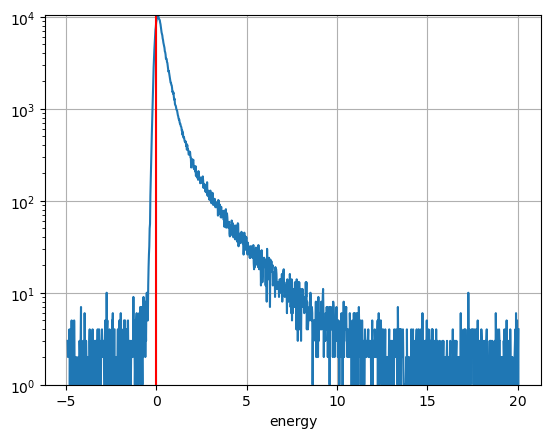

In [8]:
random_spectrum.lifetime.plot(yscale='log')
#plt.xlim([-5, centers[-1]])
plt.ylim([1, random_spectrum.lifetime.max()])
plt.axvline(0, color='red')
plt.grid()

# Inversion

In [9]:
from pyPAS.optimizer.lifetime.inversion.utils import _response_matrix
from matplotlib.colors import LogNorm
from pyPAS.optimizer.lifetime.inversion import LifetimeInvert
from pyPAS.optimizer.lifetime.inversion.tikhonov import TikhonovRegularization

In [10]:
dτ = 1e-2
τ_grid = np.arange(dτ, 5, dτ)

time_grid = random_spectrum.lifetime.energy.values
dt = (random_spectrum.lifetime.energy[1]-random_spectrum.lifetime.energy[0]).item()

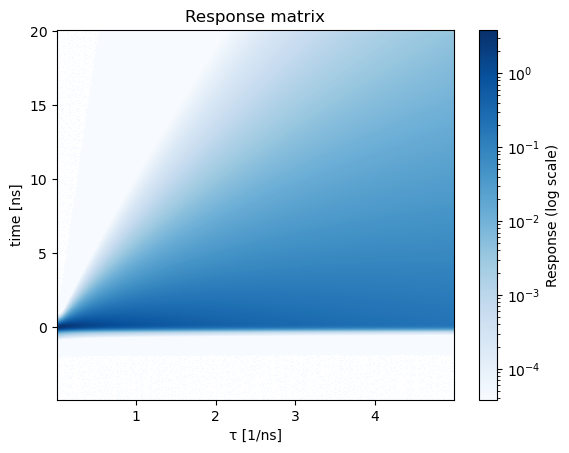

In [11]:
RM = _response_matrix(τ_grid, time_grid, IRF)
vmax = RM.max()
vmin = vmax / 1e5   # 5 orders of magnitude

plt.imshow(RM,
           cmap='Blues',
           origin='lower',
           extent=[τ_grid.min(), τ_grid.max(),
                   time_grid.min(), time_grid.max(),
                   ],
           aspect='auto',
           norm=LogNorm(vmin=vmin, vmax=vmax))

plt.colorbar(label='Response (log scale)')
plt.title('Response matrix')
plt.ylabel('time [ns]')
plt.xlabel('τ [1/ns]')
plt.show()

In [12]:
tinvert = TikhonovRegularization(random_spectrum.lifetime.energy.values, τ_grid)
q, res = tinvert.invert(random_spectrum, initial_alpha=1e-5, error=True, background_value=random_spectrum.lifetime.counts[-350:].mean())

In [13]:
# the resulted optimization gives gives integral of 1 as expected
np.trapz(q, τ_grid), res

(6527.966771550695,
  message: Optimization terminated successfully.
  success: True
   status: 0
      fun: 1.3693132778495039
        x: [-9.704e+00]
      nit: 2
    direc: [[ 6.496e-13]]
     nfev: 117)

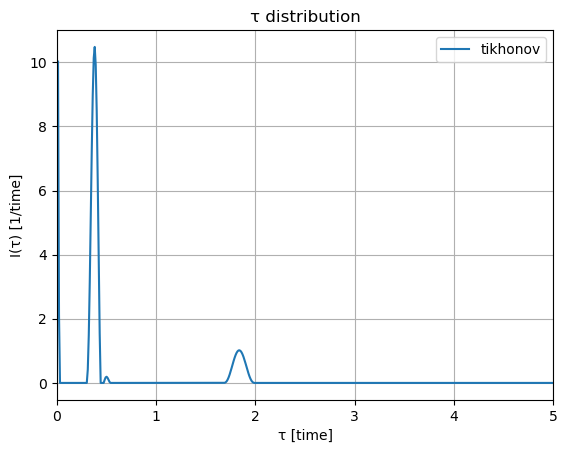

In [14]:
plt.plot(τ_grid, q/np.trapz(q,τ_grid), label='tikhonov')
plt.grid(which="both")

plt.title("τ distribution")
plt.ylabel("I(τ) [1/time]")
plt.xlabel("τ [time]")
plt.xlim([0,5])
plt.legend()

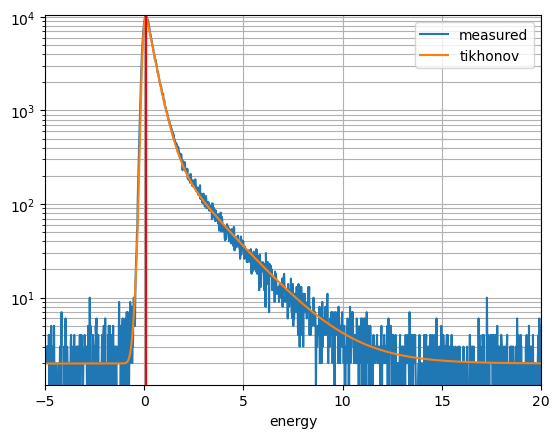

In [16]:
tikhonov_result_model = LifetimeModel('', τ_grid, q)
tikhonov_lifetime = generate_analytical_lt_spectrum(time_grid,
                                                    tikhonov_result_model,
                                                    resolution=IRF,
                                                    background_fraction=0.0)
tikhonov_lifetime.lifetime.counts *= np.trapz(q, τ_grid)
tikhonov_lifetime.lifetime.counts += random_spectrum.lifetime.counts[-350:].mean()
(random_spectrum.lifetime).plot(yscale='log', label='measured')
tikhonov_lifetime.lifetime.plot(label='tikhonov')

plt.grid(which="both")

plt.ylim([random_spectrum.lifetime.counts[:200].mean()/2, random_spectrum.lifetime.max()])

plt.xlim([-5, 20])
plt.axvline(time_grid[np.argmax(tikhonov_lifetime.lifetime.counts)])
plt.axvline(time_grid[np.argmax(random_spectrum.lifetime.counts)], color='red')

plt.legend()
plt.show()

In [51]:
import numpy as np
from scipy.optimize import minimize
from pyPAS.core.lt import PASLifetime
from pyPAS.optimizer.lifetime.inversion import LifetimeInvert
from pyPAS.optimizer.lifetime.inversion.utils import _response_matrix, _svd_truncate


class MaximalEntropyInversion(LifetimeInvert):
    """
    Inverts a positron lifetime spectrum into a lifetime distribution f(τ)
    using the Maximum Entropy Method (MELT), following Bryan (1990).

    Maximizes:  Q(f, α) = α·S(f) - L(f)

        S(f) = Σ(fᵢ - mᵢ - fᵢ log(fᵢ/mᵢ))   entropy relative to prior m (≤ 0)
        L(f) = ½·χ²                             negative log-likelihood

    f is parameterized as fᵢ = mᵢ·exp(Uᵢₜ·u) (Bryan eq. 9), restricting the
    solution to the data-visible subspace and keeping f > 0 by construction.

    Background is subtracted before normalization. Alpha and f are optimized
    jointly in log-alpha space via Powell.

    Reference: Bryan, R.K. (1990). Maximum Entropy and Bayesian Methods, 221-232.
    """

    def _entropy(self, f: np.ndarray, prior: np.ndarray) -> float:
        """
        S(f|m) = Σ(fᵢ - mᵢ - fᵢ log(fᵢ/mᵢ)) ≤ 0.
        Zero only when f == m. Penalizes deviation from the prior.
        """
        f = np.clip(f, 1e-30, None)
        return np.sum(f - prior - f * np.log(f / prior))

    def _likelihood(self,
                    f: np.ndarray,
                    U: np.ndarray,
                    V: np.ndarray,
                    sigma: np.ndarray,
                    Ut: np.ndarray,
                    data: np.ndarray,
                    data_err: np.ndarray) -> float:
        """
        L(f) = ½·χ² = ½ Σ (F_k - D_k)² / σ_k²

        Forward model via truncated SVD: F = V @ diag(σ) @ Uᵀ @ f.
        data and data_err are precomputed in invert — not recomputed here.

        Parameters
        ----------
        f        : current lifetime distribution, shape (N_tau,).
        U, V, sigma, Ut : truncated SVD components (Bryan convention).
        data     : background-subtracted normalized spectrum, shape (N_time,).
        data_err : per-channel Poisson uncertainty on data, shape (N_time,).
        """
        F = V @ (sigma * (Ut @ f))
        return 0.5 * np.sum((data - F) ** 2 / data_err ** 2)

    def _Q(self, f, alpha, prior, U, V, sigma, Ut, data, data_err) -> float:
        """Q = α·S(f) - L(f), to be maximized over f and alpha."""
        return (alpha * self._entropy(f, prior)
                - self._likelihood(f, U, V, sigma, Ut, data, data_err))

    def _f_from_u(self, u: np.ndarray, prior: np.ndarray, U: np.ndarray) -> np.ndarray:
        """
        Bryan eq. (9): fᵢ = mᵢ · exp(Uᵢₜ · u).
        Keeps f > 0 by construction and restricts solution to the
        data-visible subspace, reducing optimization from N_tau to s variables.
        """
        return prior * np.exp(U @ u)

    def _optimize_f(self, alpha, prior, U, V, sigma, Ut, data, data_err, u0):
        """
        Maximize Q over u at fixed alpha via L-BFGS-B.
        Operates in the s-dimensional subspace (s << N_tau).

        Parameters
        ----------
        alpha          : fixed regularization parameter.
        prior          : prior model, shape (N_tau,).
        U, V, sigma, Ut: truncated SVD components.
        data, data_err : precomputed normalized spectrum and uncertainties.
        u0             : warm-start vector, shape (s,).

        Returns
        -------
        f_hat : optimal distribution at this alpha, shape (N_tau,).
        u_opt : optimal subspace vector, shape (s,).
        """
        def neg_Q(u):
            return -self._Q(self._f_from_u(u, prior, U),
                            alpha, prior, U, V, sigma, Ut, data, data_err)

        result = minimize(neg_Q, u0, method='L-BFGS-B')
        return self._f_from_u(result.x, prior, U), result.x

    def _optimize(self, prior, U, V, sigma, Ut, data, data_err,
                  initial_alpha, alpha_bounds, ftol, maxiter):
        """
        Jointly optimize f and alpha via Powell in log-alpha space.
        At each Powell step, f is optimized at the proposed alpha via L-BFGS-B.
        u is warm-started between Powell steps for efficiency.

        Parameters
        ----------
        prior          : prior model, shape (N_tau,).
        U, V, sigma, Ut: truncated SVD components (Bryan convention).
        data, data_err : precomputed normalized spectrum and uncertainties.
        initial_alpha  : starting point for alpha search.
        alpha_bounds   : (min, max) search range for alpha.
        ftol           : Powell convergence tolerance.
        maxiter        : max Powell iterations.

        Returns
        -------
        alpha_opt : optimal regularization parameter.
        f_hat     : optimal lifetime distribution, shape (N_tau,).
        """
        u = np.zeros(len(sigma))

        def objective(log_alpha):
            nonlocal u
            alpha = np.exp(log_alpha)
            f_hat, u = self._optimize_f(alpha, prior, U, V, sigma, Ut, data, data_err, u)
            return -self._Q(f_hat, alpha, prior, U, V, sigma, Ut, data, data_err)

        result = minimize(
            objective,
            x0=np.log(initial_alpha),
            method='Powell',
            bounds=[(np.log(alpha_bounds[0]), np.log(alpha_bounds[1]))],
            options={"ftol": ftol, "maxiter": maxiter}
        )

        alpha_opt = np.exp(result.x.item())
        f_hat, _ = self._optimize_f(alpha_opt, prior, U, V, sigma, Ut, data, data_err, u)
        return alpha_opt, f_hat

    def _compute_covariance(self, f_hat, U, V, sigma, Ut, data_err, alpha):

        # Step 1: Ks = Ut @ diag{f} @ U  (s×s metric in singular space)
        Ks = Ut @ np.diag(f_hat) @ U
    
        # Step 2: Eigendecompose Ks = P Xi P^T  (eq. 5)
        xi, P = np.linalg.eigh(Ks)
        xi = np.maximum(xi, 0)
        sqrt_xi = np.sqrt(xi)
        # safe inverse sqrt — zero out near-singular directions
        inv_sqrt_xi = np.where(xi > 1e-10, 1.0 / np.maximum(sqrt_xi, 1e-10), 0.0)
    
        # Step 3: Ms = Sigma @ Vt @ diag{1/sigma_k^2} @ V @ Sigma
        # second derivative of L w.r.t F is diag{1/sigma_k^2} for Gaussian noise
        W = 1.0 / data_err**2
        Ms = (sigma[:, None] * V.T) * W @ (V * sigma[None, :])
    
        # Step 4: Form B = diag{sqrt_xi} @ P^T @ Ms @ P @ diag{sqrt_xi}
        # This is the matrix whose eigenvectors ARE R  (eq. 5 + surrounding text)
        B = (sqrt_xi[:, None] * P.T) @ Ms @ (P * sqrt_xi[None, :])
    
        # Step 5: Eigendecompose B -> R (eigenvectors), Lambda (eigenvalues)
        # R is NOT trivial — this is the step you were skipping
        lambdas, R = np.linalg.eigh(B)
        lambdas = np.maximum(lambdas, 0)
    
        # Step 6: Build Ys_inv = R^T @ diag{sqrt_xi} @ P^T  (eq. 6)
        Ys_inv = R.T * sqrt_xi[:, None] @ P.T   # shape (s, s)
    
        # Step 7: Recover Y from Ys_inv
        # Y = P @ diag{inv_sqrt_xi} @ R
        # because: Ys_inv @ Y = R^T diag{sqrt_xi} P^T @ P diag{inv_sqrt_xi} R
        #                     = R^T diag{sqrt_xi} diag{inv_sqrt_xi} R
        #                     = R^T R = I
        Y = P * inv_sqrt_xi[None, :] @ R        # shape (s, s)

        # Step 8: Cov(f) = diag{f} U Y diag{1/(alpha+lambda)} Y^T Ut diag{f}  (eq. 18)
        # second term of eq (18) — first term 1/alpha * diag{f} is the prior contribution
        scale = 1.0 / (alpha + lambdas)
        core = Y * scale @ Y.T                  # (s×s)
        Cov = np.diag(f_hat) @ U @ core @ Ut @ np.diag(f_hat)
    
        std = np.sqrt(np.maximum(np.diag(Cov), 0))
        return Cov, std
    
    def invert(self,
               pals: PASLifetime,
               bg_est: float = 0.0,
               noise_level: float = 1e-3,
               initial_alpha: float = 1e-3,
               alpha_bounds: tuple = (1e-10, 1e2),
               prior_model: np.ndarray = None,
               minimization_ftol: float = 1e-6,
               maxiter: int = None) -> tuple[float, np.ndarray]:
        """
        Invert a positron lifetime spectrum into a distribution f(τ).

        Parameters
        ----------
        pals              : measured lifetime spectrum with resolution function.
        bg_est            : per-channel background (counts/channel) from tail
                            estimate: np.mean(counts[time > tail_start]).
                            Subtracted before normalization. Default 0.
        t0_shift          : time-axis shift in ns from a reference measurement.
                            Applied before building the response matrix. Default 0.
        noise_level       : SVD truncation threshold relative to the largest
                            singular value. Controls rank s. Default 1e-3.
        initial_alpha     : starting alpha for the optimizer. Default 1e-3.
        alpha_bounds      : (min, max) search range for alpha. Default (1e-10, 1e2).
        prior_model       : prior over tau grid. Default flat (uniform).
        minimization_ftol : Powell convergence tolerance. Default 1e-6.
        maxiter           : max Powell iterations. Default 10 * n_tau.

        Returns
        -------
        alpha_opt : optimal regularization parameter.
        f_hat     : lifetime distribution over characteristic_time_grid.
        """
        n_tau = len(self.characteristic_time_grid)
        dtau = self.characteristic_time_grid[1] - self.characteristic_time_grid[0]

        if maxiter is None:
            maxiter = 10 * n_tau
        if prior_model is None:
            prior_model = np.ones(n_tau) / n_tau

        # Background subtraction then normalization — bg excluded from norm
        counts = pals.lifetime.counts
        net_counts = counts - bg_est
        norm = net_counts.sum()
        data = net_counts / norm
        data_err = np.sqrt(np.maximum(counts, 1)) / norm  # Poisson error on raw counts

        # Response matrix with t0 correction, then truncated SVD
        time_values = pals.lifetime.energy.values
        response = _response_matrix(self.characteristic_time_grid, time_values, pals.resolution)
        V, sigma, Ut = _svd_truncate(response * dtau, noise_level)
        U = Ut.T  # (N_tau × s) — Bryan's U, tau space

        alpha_opt, f_hat = self._optimize(
            prior=prior_model,
            U=U, V=V, sigma=sigma, Ut=Ut,
            data=data, data_err=data_err,
            initial_alpha=initial_alpha,
            alpha_bounds=alpha_bounds,
            ftol=minimization_ftol,
            maxiter=maxiter
        )
        
        cov, std = self._compute_covariance(
            f_hat=f_hat,
            U=Ut.T,
            V=V,
            sigma=sigma,
            Ut=Ut,
            data_err=data_err,
            alpha=alpha_opt
        )
        f_hat = f_hat/np.trapz(f_hat, self.characteristic_time_grid)
        std = std/np.trapz(f_hat, self.characteristic_time_grid)
        return alpha_opt, f_hat, std

In [52]:
melt = MaximalEntropyInversion(random_spectrum.lifetime.energy.values, τ_grid)

In [62]:
a1, melt_q1, std1 = melt.invert(pals=random_spectrum, maxiter=400, noise_level = 1e-3, bg_est=random_spectrum.lifetime.counts[-200:].mean())

In [63]:
a2, melt_q2, std2 = melt.invert(pals=random_spectrum, maxiter=400, noise_level = 1e-6, bg_est=random_spectrum.lifetime.counts[-200:].mean())

In [64]:
a2, a1

(7.0272633843160445e-09, 6.1637797738168905e-09)

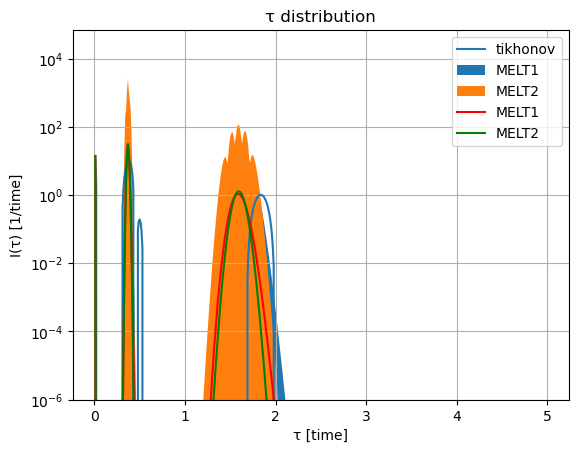

In [65]:
plt.plot(τ_grid, q/np.trapz(q,τ_grid), label='tikhonov')
plt.fill_between(τ_grid, y1=melt_q1+std1, y2=melt_q1-std1, label='MELT1')
plt.fill_between(τ_grid, y1=melt_q2+std2, y2=melt_q2-std2, label='MELT2')
plt.plot(τ_grid, melt_q1/np.trapz(melt_q1,τ_grid), color='red', label='MELT1')
plt.plot(τ_grid, melt_q2/np.trapz(melt_q2,τ_grid), color='green', label='MELT2')
plt.yscale("log")
#plt.xscale("log")

plt.ylim([1e-6, np.max([melt_q1.max(),melt_q2.max(),q.max()])])
plt.grid(which="both")

plt.title("τ distribution")
plt.ylabel("I(τ) [1/time]")
plt.xlabel("τ [time]")

plt.legend()
plt.show()

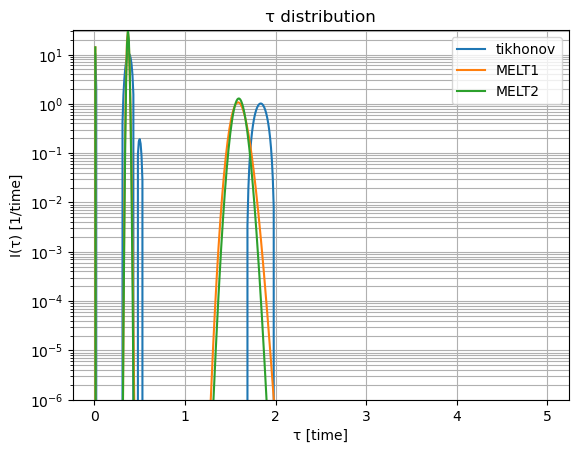

In [66]:
plt.plot(τ_grid, q/np.trapz(q,τ_grid), label='tikhonov')
plt.plot(τ_grid, melt_q1/np.trapz(melt_q1,τ_grid), label='MELT1')
plt.plot(τ_grid, melt_q2/np.trapz(melt_q2,τ_grid), label='MELT2')

plt.yscale("log")
#plt.xscale("log")

plt.ylim([1e-6, np.max([melt_q1.max()/np.trapz(melt_q1,τ_grid),melt_q2.max()/np.trapz(melt_q2,τ_grid),q.max()/np.trapz(q,τ_grid)])])
plt.grid(which="both")

plt.title("τ distribution")
plt.ylabel("I(τ) [1/time]")
plt.xlabel("τ [time]")

plt.legend()
plt.show()

In [28]:
melt_q2.max()

31.302573398258307

In [144]:
np.trapz(melt_q2, x=τ_grid)

0.018592742499380588

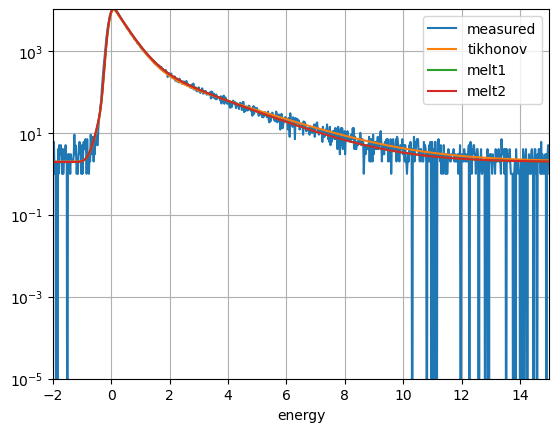

In [176]:
melt_result_model1 = LifetimeModel('', τ_grid, melt_q1/np.trapz(melt_q1,τ_grid))
melt_result_model2 = LifetimeModel('', τ_grid, melt_q2/np.trapz(melt_q2,τ_grid))

melt_lifetime1 = generate_analytical_lt_spectrum(time_grid,
                                                    melt_result_model1,
                                                    resolution=IRF,
                                                    background_fraction=0.00)
melt_lifetime2 = generate_analytical_lt_spectrum(time_grid,
                                                    melt_result_model2,
                                                    resolution=IRF,
                                                    background_fraction=0.00)
norm = random_spectrum.lifetime.integrate('energy').item()
melt_lifetime1.lifetime.counts *= norm
melt_lifetime2.lifetime.counts *= norm
melt_lifetime1.lifetime.counts += random_spectrum.lifetime.counts[-200:].mean()
melt_lifetime2.lifetime.counts += random_spectrum.lifetime.counts[-200:].mean()
(random_spectrum.lifetime).plot(yscale='log', label='measured')
tikhonov_lifetime.lifetime.plot(label='tikhonov')
melt_lifetime1.lifetime.plot(label='melt1')
melt_lifetime2.lifetime.plot(label='melt2')
plt.grid(which="both")

plt.ylim([1e-5, random_spectrum.lifetime.max()])
plt.xlim([-2, 15])


plt.legend()

In [2]:
melt_result_model1.

SyntaxError: invalid syntax (2101814426.py, line 1)

In [119]:
(((random_spectrum.lifetime.counts - melt_lifetime2.lifetime.counts)/(1+random_spectrum.lifetime.counts)).sum())/len(random_spectrum.lifetime.counts)

-0.0003090245082435556

In [267]:
(((random_spectrum.lifetime.counts - melt_lifetime1.lifetime.counts)/(1+random_spectrum.lifetime.counts)).sum())/len(random_spectrum.lifetime.counts)

0.0025993551328690654

In [54]:
eg = 170
em = 511
t = np.pi

eg - eg/(1+eg/em*(1-np.cos(t)))

67.92009400705052

In [ ]:
import numpy as np
import xarray as xr
from scipy.optimize import minimize, nnls
from pyPAS.core.lt import PASLifetime
from pyPAS.optimizer.lifetime.inversion import LifetimeInvert
from pyPAS.optimizer.lifetime.inversion.utils import _response_matrix, _svd_truncate

class MELTInversion(LifetimeInvert):
    """
    Inverts a positron lifetime spectrum into a lifetime distribution q(τ)
    using the Maximum Entropy method (MELT).

    The inversion maximizes:
        S(q) - α · χ²(q)

    where S(q) = -Σ qᵢ log(qᵢ/mᵢ) is the relative entropy with respect to
    a default model m, and χ² measures fit quality. α is determined
    automatically within the Bayesian framework.

    The response matrix is first cleaned via SVD truncation — singular values
    below the noise threshold are discarded, removing noise-dominated directions
    before the MaxEnt optimization.
    """


    def _entropy(self, q: np.ndarray, prior_model: np.ndarray) -> float:
        """
        Relative Shannon entropy of q with respect to default model m.

            S(q) = -Σ qᵢ log(qᵢ / mᵢ)

        Parameters
        ----------
        q : np.ndarray
            Current lifetime distribution (must be positive).
        prior_model : np.ndarray
            Prior default model over tau grid. Flat if no prior knowledge.

        Returns
        -------
        float
            Entropy value (positive when q ≈ m).
        """
        q_safe = np.clip(q, 1e-30, None)
        return -np.sum(q_safe * np.log(q_safe / prior_model))

    def _chi_sq(self,
                q: np.ndarray,
                U: np.ndarray,
                s: np.ndarray,
                Vt: np.ndarray,
                normlized_pals: np.ndarray,
                normlized_pals_err: np.ndarray) -> float:
        """
        Chi-squared residual in the truncated SVD space.

        Parameters
        ----------
        q : np.ndarray
            Current lifetime distribution.
        U, s, Vt : np.ndarray
            Truncated SVD components of the scaled response matrix.
        normlized_pals : np.ndarray
            Normalized measured spectrum.
        normlized_pals_err : np.ndarray
            Poisson uncertainty on normalized spectrum.

        Returns
        -------
        float
            Chi-squared value.
        """
        lifetime_q = U @ (s * (Vt @ q))  # = response_clean @ q
        mask = normlized_pals > 0
        residuals = (normlized_pals[mask] - lifetime_q[mask]) ** 2
        return np.sum(residuals / normlized_pals_err[mask] ** 2)

    def _melt_objective(self,
                        log_q: np.ndarray,
                        alpha: float,
                        U: np.ndarray,
                        s: np.ndarray,
                        Vt: np.ndarray,
                        normlized_pals: np.ndarray,
                        normlized_pals_err: np.ndarray,
                        default_model: np.ndarray) -> float:
        """
        MELT objective function: α·χ²(q) - S(q), minimized over log(q).

        Parameterized in log space to enforce q > 0 without constraints.

        Parameters
        ----------
        log_q : np.ndarray
            Log of the lifetime distribution (optimization variable).
        alpha : float
            Entropy weight — balances fit fidelity against entropy.
        U, s, Vt : np.ndarray
            Truncated SVD components.
        normlized_pals : np.ndarray
            Normalized measured spectrum.
        normlized_pals_err : np.ndarray
            Poisson uncertainty.
        default_model : np.ndarray
            Prior default model for entropy calculation.

        Returns
        -------
        float
            Objective value.
        """
        q = np.exp(log_q)
        chi2 = self._chi_sq(q, U, s, Vt, normlized_pals, normlized_pals_err)
        entropy = self._entropy(q, default_model)
        return alpha * chi2 - entropy

    def _find_alpha(self,
                    log_q: np.ndarray,
                    U: np.ndarray,
                    s: np.ndarray,
                    Vt: np.ndarray,
                    normlized_pals: np.ndarray,
                    normlized_pals_err: np.ndarray,
                    default_model: np.ndarray,
                    n_good: int,
                    alpha_bounds: tuple,
                    ftol: float) -> float:
        """
        Determine optimal alpha by matching χ² ≈ n_good (number of
        retained singular values) — the Bayesian evidence criterion.

        Parameters
        ----------
        log_q : np.ndarray
            Current log distribution (warm start).
        n_good : int
            Number of retained singular values — target for χ².
        alpha_bounds : tuple
            (min, max) bounds for alpha search.
        ftol : float
            Convergence tolerance.

        Returns
        -------
        float
            Optimal alpha.
        """
        def chi_sq_gap(log_alpha):
            alpha = float(np.exp(log_alpha[0]))
            res = minimize(
                self._melt_objective,
                x0=log_q,
                args=(alpha, U, s, Vt, normlized_pals, normlized_pals_err, default_model),
                method="L-BFGS-B",
                options={"ftol": ftol, "maxiter":100}
            )
            q = np.exp(res.x)
            chi2 = self._chi_sq(q, U, s, Vt, normlized_pals, normlized_pals_err)
            return (chi2 - n_good) ** 2  # drive χ² → n_good

        res = minimize(
            chi_sq_gap,
            x0=[np.log(1e-3)],
            bounds=[(np.log(alpha_bounds[0]), np.log(alpha_bounds[1]))],
            method="Powell",
            options={"ftol": ftol, "maxiter":100},
            
        )
        return float(np.exp(res.x[0]))

    def invert(self,
               pals: PASLifetime,
               maxiter=None,
               noise_level=1e-10,
               initial_alpha=1e-3,
               alpha_bounds=(1e-10, 1e2),
               prior_model=None,
               minimization_ftol=1e-6) -> tuple[np.ndarray, object]:
        """
        Invert a lifetime spectrum into a lifetime distribution q(τ) via MELT.

        Parameters
        ----------
        pals : PASLifetime
            Measured lifetime spectrum with resolution function.
        maxiter : int, optional
            Max iterations for inner optimizer. Defaults to 10 * n_tau.
        noise_level : float
            SVD truncation threshold relative to largest singular value.
            Default 1e-3.
        initial_alpha : float
            Starting alpha for Bayesian evidence search. Default 1e-3.
        alpha_bounds : tuple
            (min, max) bounds for alpha. Default (1e-10, 1e2).
        prior_model : np.ndarray, optional
            Prior over tau grid. Defaults to flat (uniform) model.
        minimization_ftol : float
            Convergence tolerance. Default 1e-6.

        Returns
        -------
        q : np.ndarray
            Recovered lifetime distribution over characteristic_time_grid.
        res : OptimizeResult
            Final scipy optimization result.
        """
        if maxiter is None:
            maxiter = 10 * self.characteristic_time_grid.shape[0]

        n_tau = len(self.characteristic_time_grid)
        dtau = self.characteristic_time_grid[1] - self.characteristic_time_grid[0]

        if prior_model is None:
            prior_model = np.ones(n_tau) / (self.characteristic_time_grid[-1] - self.characteristic_time_grid[0])  # flat prior

        # ---- normalize data ----
        counts = pals.lifetime.counts
        norm = pals.lifetime.integrate('energy').item()
        normlized_pals = counts / norm
        normlized_pals_err = np.sqrt(counts) / norm

        # ---- build and clean response matrix ----
        response = _response_matrix(
            self.characteristic_time_grid,
            pals.lifetime.energy.values,
            pals.resolution
        )
        U, s, Vt = _svd_truncate(response * dtau, noise_level)
        n_good = len(s)  # number of retained singular values

        # ---- find optimal alpha ----
        log_q0 = np.log(default_model)
        alpha_opt = self._find_alpha(
            log_q=log_q0,
            U=U, s=s, Vt=Vt,
            normlized_pals=normlized_pals,
            normlized_pals_err=normlized_pals_err,
            default_model=default_model,
            n_good=n_good,
            alpha_bounds=alpha_bounds,
            ftol=minimization_ftol
        )

        # ---- final solution at optimal alpha ----
        res = minimize(
            self._melt_objective,
            x0=log_q0,
            args=(alpha_opt, U, s, Vt, normlized_pals, normlized_pals_err, default_model),
            method="L-BFGS-B",
            options={"ftol": minimization_ftol, "maxiter": maxiter}
        )

        q = np.exp(res.x)
        return q, res